# JMD Implementation
Implementing the Jump Plus AM-FM Mode Decomposition algorithm, validating on synthetic data, and testing on real PCG signals.

In [1]:
import numpy as np
from scipy.fft import fft, ifft, fftshift, ifftshift
from scipy.sparse import spdiags, diags, eye as speye
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import json
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

PROJECT_ROOT = Path(r"D:\sop")
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
SAMPLE_RATE = 1000

print("Ready.")

Ready.


## Helper functions

In [2]:
def mirror_extend_matlab(signal):
    """
    Mirror-extends the signal to length 2T using quarter-based padding.

    MATLAB reference:
        f_mirror(1:T/2) = signal(T/2:-1:1)
        f_mirror(T/2+1:3*T/2) = signal
        f_mirror(3*T/2+1:2*T) = signal(T:-1:T/2+1)
    """
    T = len(signal)
    T_half = T // 2

    f = np.zeros(2 * T)
    f[0:T_half] = signal[T_half-1::-1]
    f[T_half:T_half + T] = signal
    f[T_half + T:2*T] = signal[T-1:T_half-1:-1]

    return f


def compute_alpha_schedule(alpha, N=2000):
    """
    Computing the alpha warm-up schedule.

    MATLAB reference:
        a2 = 50
        t2 = 0.01:0.001:sqrt(2/a2)
        phi1 = (-a2/2) * (t2.^2) + (sqrt(2*a2)*t2)
        phi = [phi1, ones(1, N-length(phi1))]
        Alpha = alpha * phi
    """
    a2 = 50
    t2 = np.arange(0.01, np.sqrt(2/a2) + 0.001, 0.001)
    phi1 = (-a2/2) * (t2**2) + (np.sqrt(2*a2) * t2)
    phi = np.concatenate([phi1, np.ones(N - len(phi1))])
    return alpha * phi

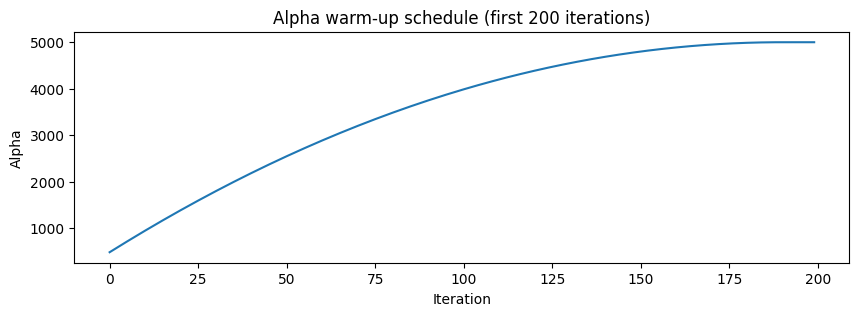

In [3]:
# visualising the alpha warm-up schedule

Alpha_test = compute_alpha_schedule(5000)
plt.figure(figsize=(10, 3))
plt.plot(Alpha_test[:200])
plt.xlabel('Iteration')
plt.ylabel('Alpha')
plt.title('Alpha warm-up schedule (first 200 iterations)')
plt.show()

## Core JMD algorithm

In [4]:
def JMD(signal, alpha=5000, tau=5, beta=0.03, b_bar=0.45, K=3, init=0, tol=1e-6):
    """
    Jump Plus AM-FM Mode Decomposition (JMD) - Memory Efficient Version.
    Only stores current and previous iteration buffers.

    Parameters:
        signal : 1D array
        alpha  : bandwidth constraint
        tau    : dual ascent step (0 for noisy signals)
        beta   : jump constraint (1/expected number of jumps)
        b_bar  : jump height parameter
        K      : number of modes to recover
        init   : 0=zeros, 1=uniform, 2=random
        tol    : convergence tolerance

    Returns:
        u     : (K, T) decomposed oscillatory modes
        v     : (T,) jump component
        omega : (K,) final center frequencies
    """
    shift = np.mean(signal)
    signal = signal - shift

    save_T = len(signal)
    fs = 1.0 / save_T

    f = mirror_extend_matlab(signal)
    T = len(f)

    t = np.arange(1, T + 1) / T
    freqs = t - 0.5 - 1/T

    N = 2000
    Alpha = compute_alpha_schedule(alpha, N)

    f_hat = fftshift(fft(f))
    f_hat_plus = f_hat.copy()
    f_hat_plus[:T//2] = 0

    u_hat_curr = np.zeros((T, K), dtype=np.complex128)
    u_hat_prev = np.zeros((T, K), dtype=np.complex128)

    omega_curr = np.zeros(K)
    omega_prev = np.zeros(K)

    if init == 1:
        for i in range(K):
            omega_prev[i] = (0.5 / K) * i
    elif init == 2:
        omega_prev[:] = np.sort(np.exp(np.log(fs) + (np.log(0.5) - np.log(fs)) * np.random.rand(K)))

    uDiff = tol + np.finfo(float).eps
    n = 0

    b = 2.0 / (b_bar ** 2)
    gamma = tau * (0.5 * b * beta)
    v = np.zeros(T)

    d = np.ones(T)
    D = spdiags(np.vstack([-d, d]), np.array([0, 1]), T, T, format='csr')
    D = D.tolil()
    D[-1, :] = 0
    D = D.tocsr()
    DTD = D.T @ D

    x = np.zeros(T)
    rho = np.zeros(T)
    coef1 = 1.0 / gamma if gamma > 0 else 0
    mu = 2 * beta / gamma if gamma > 0 else 0
    SPDiag = speye(T, format='csr')

    j_hat_curr = np.zeros(T, dtype=np.complex128)
    j_hat_prev = np.zeros(T, dtype=np.complex128)

    if gamma > 0:
        v_update_matrix = SPDiag + gamma * DTD

    while uDiff > tol and n < N - 1:
        sum_uk = np.sum(u_hat_prev, axis=1) - u_hat_prev[:, 0]

        for k in range(K):
            if k > 0:
                sum_uk = sum_uk + u_hat_curr[:, k-1] - u_hat_prev[:, k]

            denom = 1 + Alpha[n] * (freqs - omega_prev[k])**2
            u_hat_curr[:, k] = (f_hat_plus - sum_uk - j_hat_prev) / denom

            pos_freqs = freqs[T//2:]
            pos_power = np.abs(u_hat_curr[T//2:, k])**2
            sum_power = np.sum(pos_power)
            if sum_power > 0:
                omega_curr[k] = np.sum(pos_freqs * pos_power) / sum_power

        u_hat_full = np.zeros((T, K), dtype=np.complex128)
        for k in range(K):
            u_hat_full[T//2:, k] = u_hat_curr[T//2:, k]
            u_hat_full[T//2:0:-1, k] = np.conj(u_hat_curr[T//2:, k])
            u_hat_full[0, k] = np.conj(u_hat_full[-1, k])

        u = np.zeros((K, T))
        for k in range(K):
            u[k, :] = np.real(ifft(ifftshift(u_hat_full[:, k])))

        if gamma > 0:
            rhs = (gamma * D.T @ x - D.T @ rho) + f - np.sum(u, axis=0)
            v = spsolve(v_update_matrix, rhs)
        else:
            v = f - np.sum(u, axis=0)

        Dv = D @ v
        h = Dv + coef1 * rho

        if mu * b < 1:
            abs_h = np.abs(h) + 1e-10
            scale = np.clip((1.0 / (1 - mu * b)) - (mu * np.sqrt(2 * b) / (1 - mu * b)) / abs_h, 0, 1)
            x = scale * h
        else:
            x = np.zeros_like(h)

        rho = rho - gamma * (x - Dv)
        v = v - (np.mean(v) - np.mean(f))

        j_hat_curr[:] = fftshift(fft(v))
        j_hat_curr[:T//2] = 0

        n += 1

        uDiff = np.finfo(float).eps
        for k in range(K):
            diff = u_hat_curr[:, k] - u_hat_prev[:, k]
            uDiff += (1/T) * np.sum(diff * np.conj(diff)).real
        j_diff = j_hat_curr - j_hat_prev
        uDiff += (1/T) * np.sum(j_diff * np.conj(j_diff)).real
        uDiff = np.abs(uDiff)

        u_hat_prev[:] = u_hat_curr
        omega_prev[:] = omega_curr
        j_hat_prev[:] = j_hat_curr

    u_hat_final = np.zeros((T, K), dtype=np.complex128)
    u_hat_final[T//2:, :] = u_hat_curr[T//2:, :]
    u_hat_final[T//2:0:-1, :] = np.conj(u_hat_curr[T//2:, :])
    u_hat_final[0, :] = np.conj(u_hat_final[-1, :])

    u = np.zeros((K, T))
    for k in range(K):
        u[k, :] = np.real(ifft(ifftshift(u_hat_final[:, k])))

    u = u[:, T//4:3*T//4]
    v = v[T//4:3*T//4] + shift

    sort_idx = np.argsort(omega_curr)
    u = u[sort_idx, :]
    omega_final = omega_curr[sort_idx]

    return u, v, omega_final

## Validating on synthetic signal
Three sinusoids (4 Hz, 80 Hz, 200 Hz) + a step-function jump + noise.

Signal: 1000 samples, 1000 Hz
Components: 4 Hz, 80 Hz, 200 Hz + jumps + noise


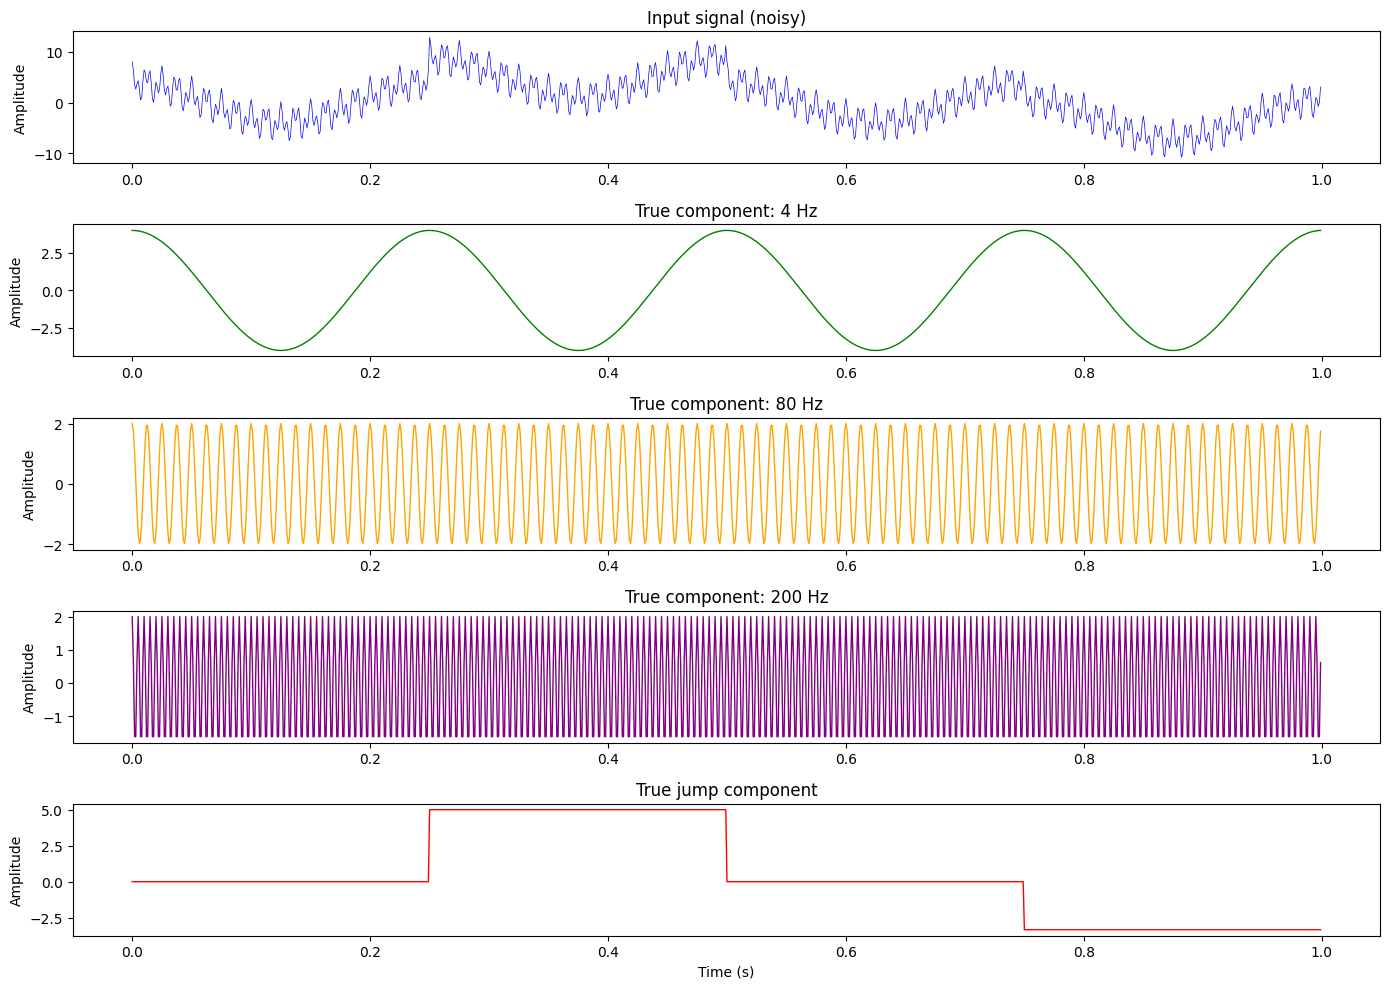

In [5]:
# creating a synthetic test signal

np.random.seed(42)

SampFreq = 1000
t = np.arange(0, 1, 1/SampFreq)
N = len(t)

IF1, IF2, IF3 = 4, 80, 200
Sig1 = 4 * np.cos(2 * IF1 * np.pi * t)
Sig2 = 2 * np.cos(2 * IF2 * np.pi * t)
Sig3 = 2 * np.cos(2 * IF3 * np.pi * t)

jump = np.zeros(N)
jump[N//4:N//2] = 3.0
jump[3*N//4:] = -2.0
jump = 5 * jump / 3

Sig = Sig1 + Sig2 + Sig3 + jump + 0.1 * np.random.randn(N)

print(f"Signal: {N} samples, {SampFreq} Hz")
print(f"Components: {IF1} Hz, {IF2} Hz, {IF3} Hz + jumps + noise")

fig, axes = plt.subplots(5, 1, figsize=(14, 10))
axes[0].plot(t, Sig, 'b', linewidth=0.5)
axes[0].set_title('Input signal (noisy)')
axes[0].set_ylabel('Amplitude')

for i, (sig, freq, color) in enumerate([(Sig1, IF1, 'g'), (Sig2, IF2, 'orange'), (Sig3, IF3, 'purple')]):
    axes[i+1].plot(t, sig, color, linewidth=1)
    axes[i+1].set_title(f'True component: {freq} Hz')
    axes[i+1].set_ylabel('Amplitude')

axes[4].plot(t, jump, 'r', linewidth=1)
axes[4].set_title('True jump component')
axes[4].set_xlabel('Time (s)')
axes[4].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [6]:
# running JMD on the synthetic signal

start_time = time.time()
u, v, omega = JMD(Sig, alpha=5000, tau=5, beta=0.03, b_bar=0.45, K=3, init=0, tol=1e-6)
elapsed = time.time() - start_time

print(f"Completed in {elapsed:.2f} seconds")
print(f"\nExtracted center frequencies:")
for k in range(3):
    print(f"  Mode {k+1}: {omega[k]*SampFreq:.1f} Hz")

Completed in 10.52 seconds

Extracted center frequencies:
  Mode 1: 4.0 Hz
  Mode 2: 80.0 Hz
  Mode 3: 80.2 Hz


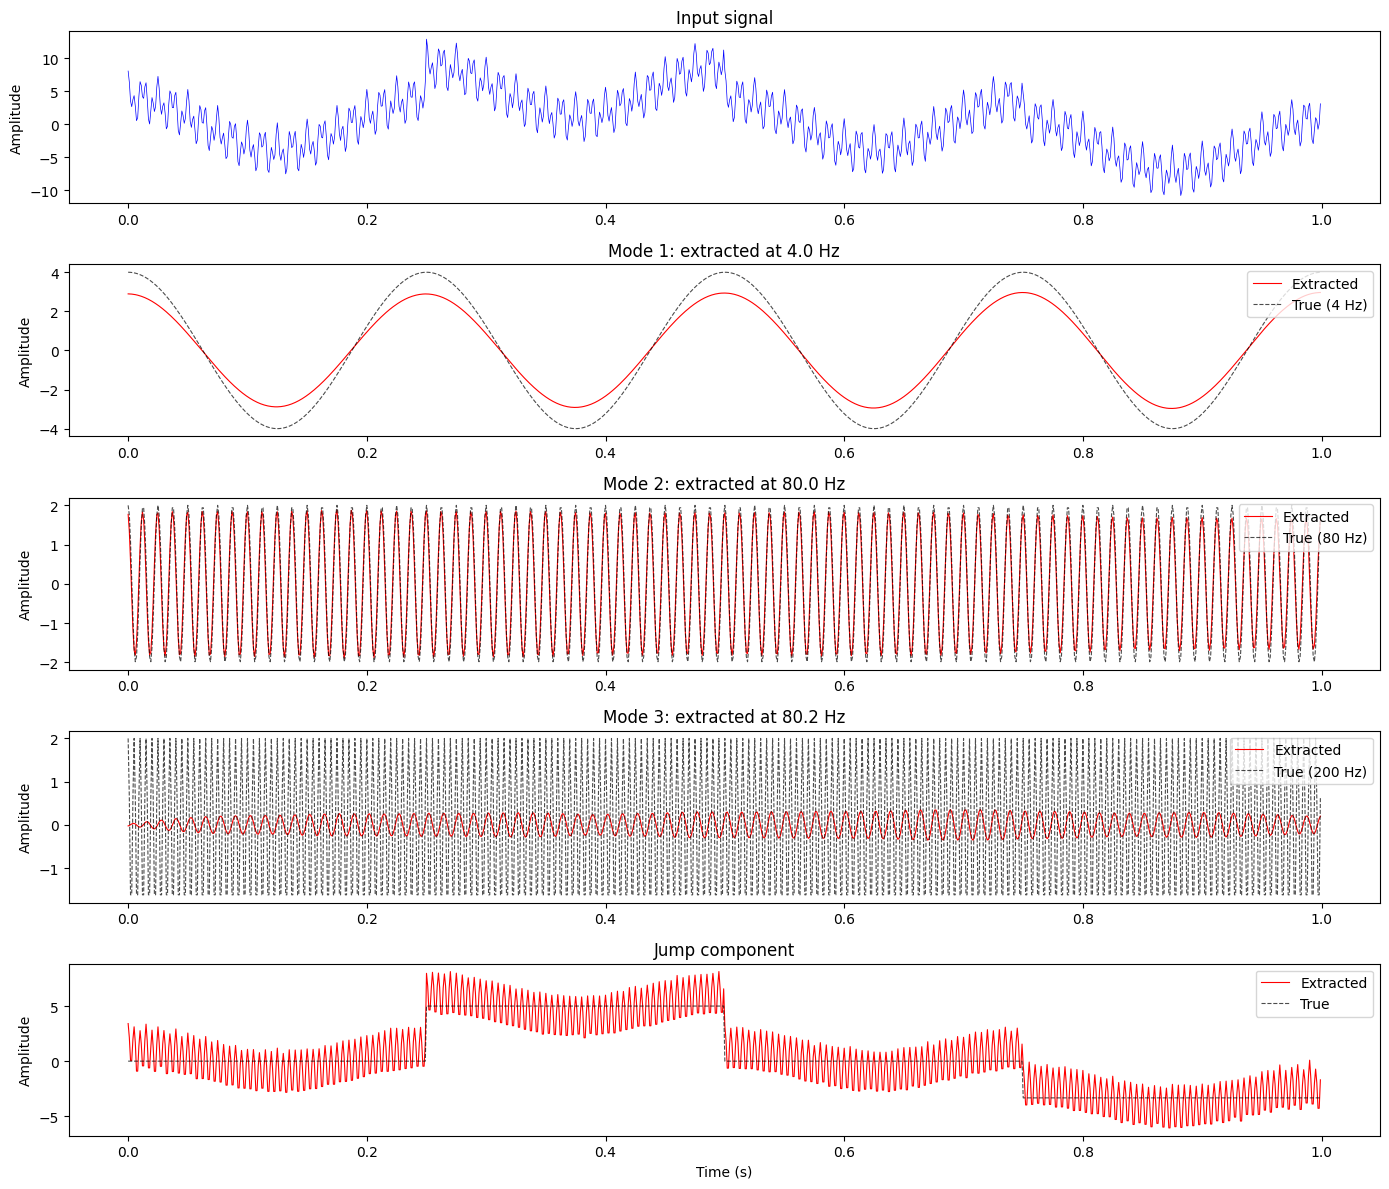

Reconstruction RMSE: 0.042046


In [7]:
# comparing extracted modes with the true components

fig, axes = plt.subplots(5, 1, figsize=(14, 12))

axes[0].plot(t, Sig, 'b', linewidth=0.5)
axes[0].set_title('Input signal')
axes[0].set_ylabel('Amplitude')

true_signals = [Sig1, Sig2, Sig3]
true_freqs = [IF1, IF2, IF3]

for k in range(3):
    axes[k+1].plot(t, u[k], 'r', linewidth=0.8, label='Extracted')
    axes[k+1].plot(t, true_signals[k], 'k--', linewidth=0.8, alpha=0.7, label=f'True ({true_freqs[k]} Hz)')
    axes[k+1].set_title(f'Mode {k+1}: extracted at {omega[k]*SampFreq:.1f} Hz')
    axes[k+1].set_ylabel('Amplitude')
    axes[k+1].legend(loc='upper right')

axes[4].plot(t, v, 'r', linewidth=0.8, label='Extracted')
axes[4].plot(t, jump, 'k--', linewidth=0.8, alpha=0.7, label='True')
axes[4].set_title('Jump component')
axes[4].set_xlabel('Time (s)')
axes[4].set_ylabel('Amplitude')
axes[4].legend(loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'jmd_synthetic_test.png', dpi=150, bbox_inches='tight')
plt.show()

reconstruction = np.sum(u, axis=0) + v
rmse = np.sqrt(np.mean((Sig - reconstruction)**2))
print(f"Reconstruction RMSE: {rmse:.6f}")

## Testing on real PCG signals
Loading one absent and one present signal from the preprocessed data. Using the first 5 seconds (5,000 samples) for a quick validation; full-length processing happens in the batch decomposition step.

In [8]:
# loading metadata and picking one sample from each class

df = pd.read_csv(PROJECT_ROOT / 'data' / 'file_metadata.csv')

absent_row = df[(df['class'] == 'absent') & (~df['is_augmented'])].iloc[0]
present_row = df[(df['class'] == 'present') & (~df['is_augmented'])].iloc[0]

signal_absent_full = np.load(absent_row['npy_path'])
signal_present_full = np.load(present_row['npy_path'])

# using first 5 seconds for the demo
n_samples = 5 * SAMPLE_RATE
signal_absent = signal_absent_full[:n_samples]
signal_present = signal_present_full[:n_samples]

print(f"Absent:  {absent_row['file']} ({len(signal_absent_full)} samples, using first {n_samples})")
print(f"Present: {present_row['file']} ({len(signal_present_full)} samples, using first {n_samples})")

Absent:  a100_AV.wav (30256 samples, using first 5000)
Present: p100_AV.wav (20000 samples, using first 5000)


In [9]:
# initial PCG parameters (will be tuned properly in Block 4)

pcg_params = {
    'alpha': 2000,
    'tau': 5,
    'beta': 0.03,
    'b_bar': 0.3,
    'K': 4,
    'init': 0,
    'tol': 1e-6
}

print("PCG parameters:")
for k, val in pcg_params.items():
    print(f"  {k}: {val}")

PCG parameters:
  alpha: 2000
  tau: 5
  beta: 0.03
  b_bar: 0.3
  K: 4
  init: 0
  tol: 1e-06


In [10]:
# decomposing the absent sample

start_time = time.time()
u_absent, v_absent, omega_absent = JMD(signal_absent, **pcg_params)
print(f"Completed in {time.time() - start_time:.2f}s")
print(f"Center frequencies: {omega_absent * SAMPLE_RATE} Hz")

Completed in 38.45s
Center frequencies: [ 33.68213471  70.73640696 101.3224838  326.3160198 ] Hz


In [11]:
# decomposing the present sample

start_time = time.time()
u_present, v_present, omega_present = JMD(signal_present, **pcg_params)
print(f"Completed in {time.time() - start_time:.2f}s")
print(f"Center frequencies: {omega_present * SAMPLE_RATE} Hz")

Completed in 34.23s
Center frequencies: [ 31.65006927  68.52360356 171.79256839 267.05090445] Hz


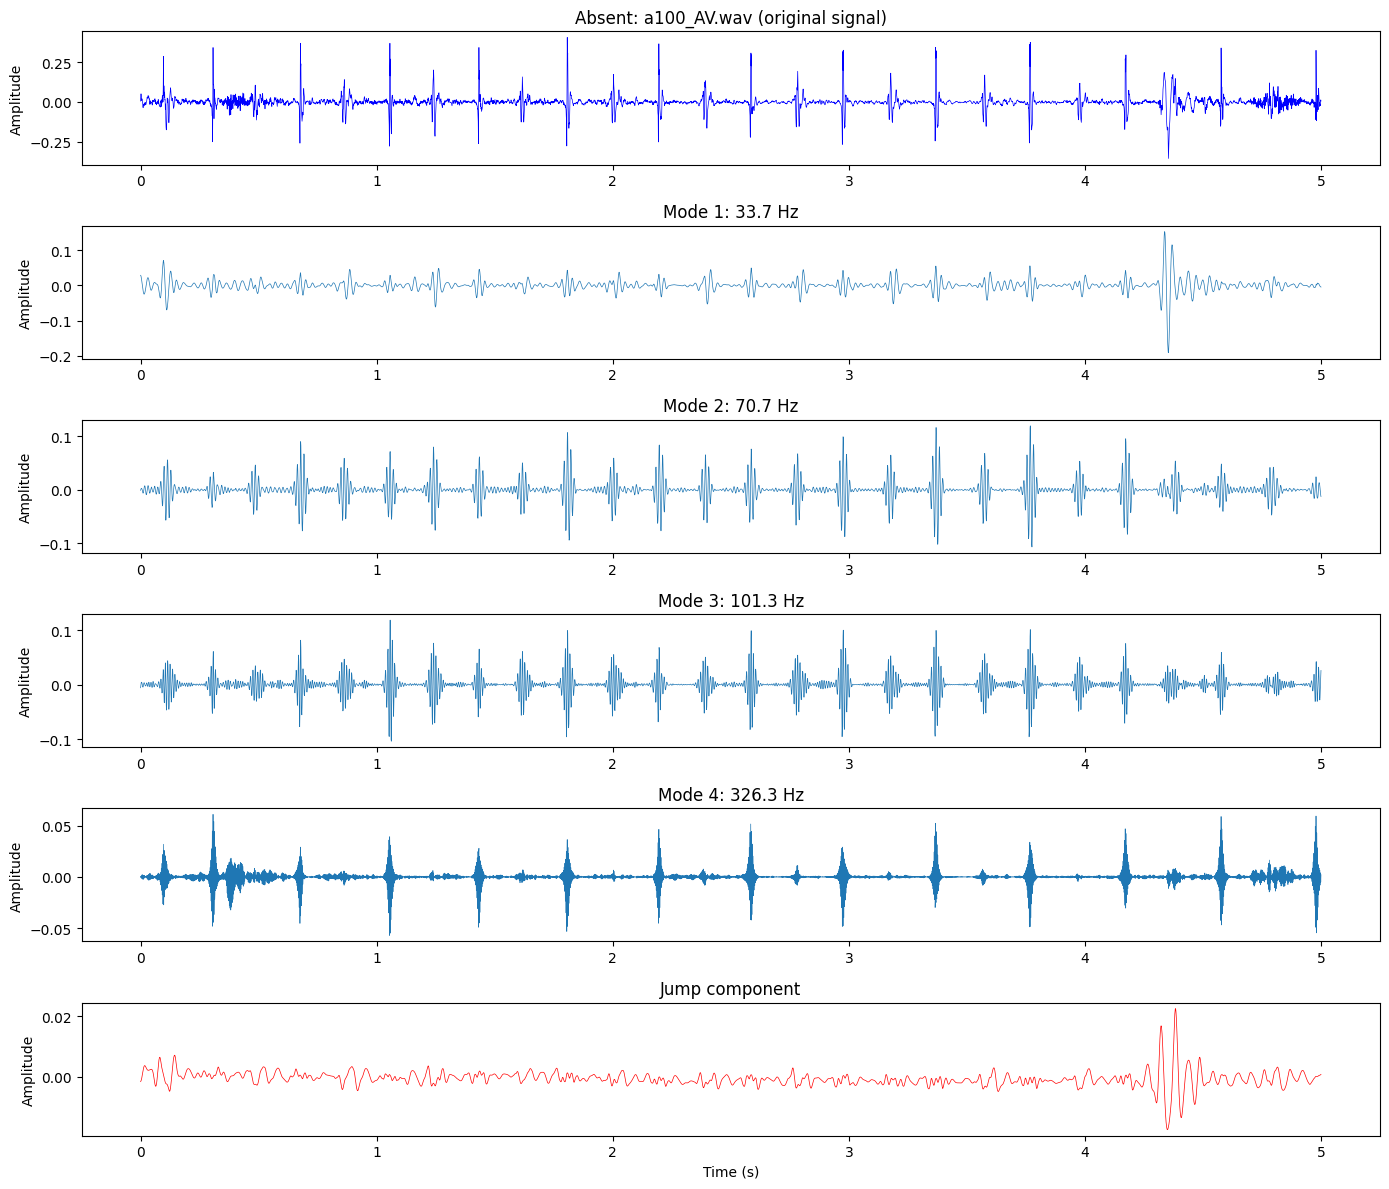

In [12]:
# plotting absent decomposition

K = pcg_params['K']
time_axis = np.arange(len(signal_absent)) / SAMPLE_RATE

fig, axes = plt.subplots(K + 2, 1, figsize=(14, 12))

axes[0].plot(time_axis, signal_absent, 'b', linewidth=0.5)
axes[0].set_title(f'Absent: {absent_row["file"]} (original signal)')
axes[0].set_ylabel('Amplitude')

for k in range(K):
    axes[k+1].plot(time_axis, u_absent[k], linewidth=0.5)
    axes[k+1].set_title(f'Mode {k+1}: {omega_absent[k]*SAMPLE_RATE:.1f} Hz')
    axes[k+1].set_ylabel('Amplitude')

axes[-1].plot(time_axis, v_absent, 'r', linewidth=0.5)
axes[-1].set_title('Jump component')
axes[-1].set_xlabel('Time (s)')
axes[-1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'jmd_pcg_absent.png', dpi=150, bbox_inches='tight')
plt.show()

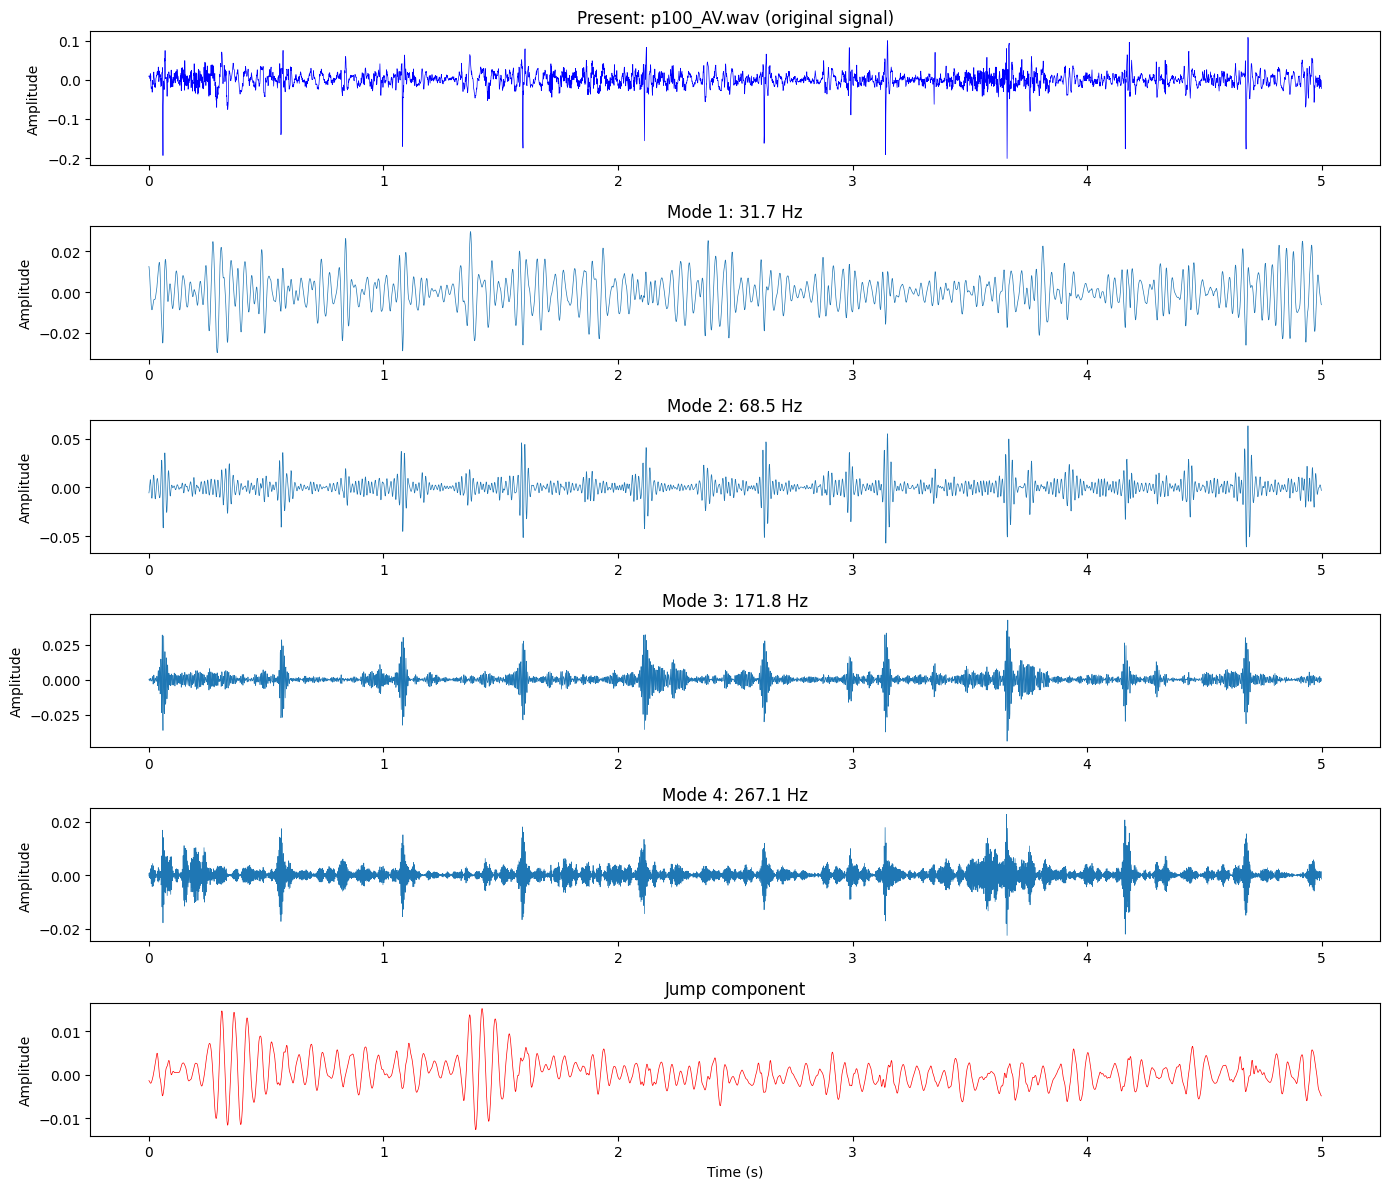

In [13]:
# plotting present decomposition

time_axis = np.arange(len(signal_present)) / SAMPLE_RATE

fig, axes = plt.subplots(K + 2, 1, figsize=(14, 12))

axes[0].plot(time_axis, signal_present, 'b', linewidth=0.5)
axes[0].set_title(f'Present: {present_row["file"]} (original signal)')
axes[0].set_ylabel('Amplitude')

for k in range(K):
    axes[k+1].plot(time_axis, u_present[k], linewidth=0.5)
    axes[k+1].set_title(f'Mode {k+1}: {omega_present[k]*SAMPLE_RATE:.1f} Hz')
    axes[k+1].set_ylabel('Amplitude')

axes[-1].plot(time_axis, v_present, 'r', linewidth=0.5)
axes[-1].set_title('Jump component')
axes[-1].set_xlabel('Time (s)')
axes[-1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'jmd_pcg_present.png', dpi=150, bbox_inches='tight')
plt.show()

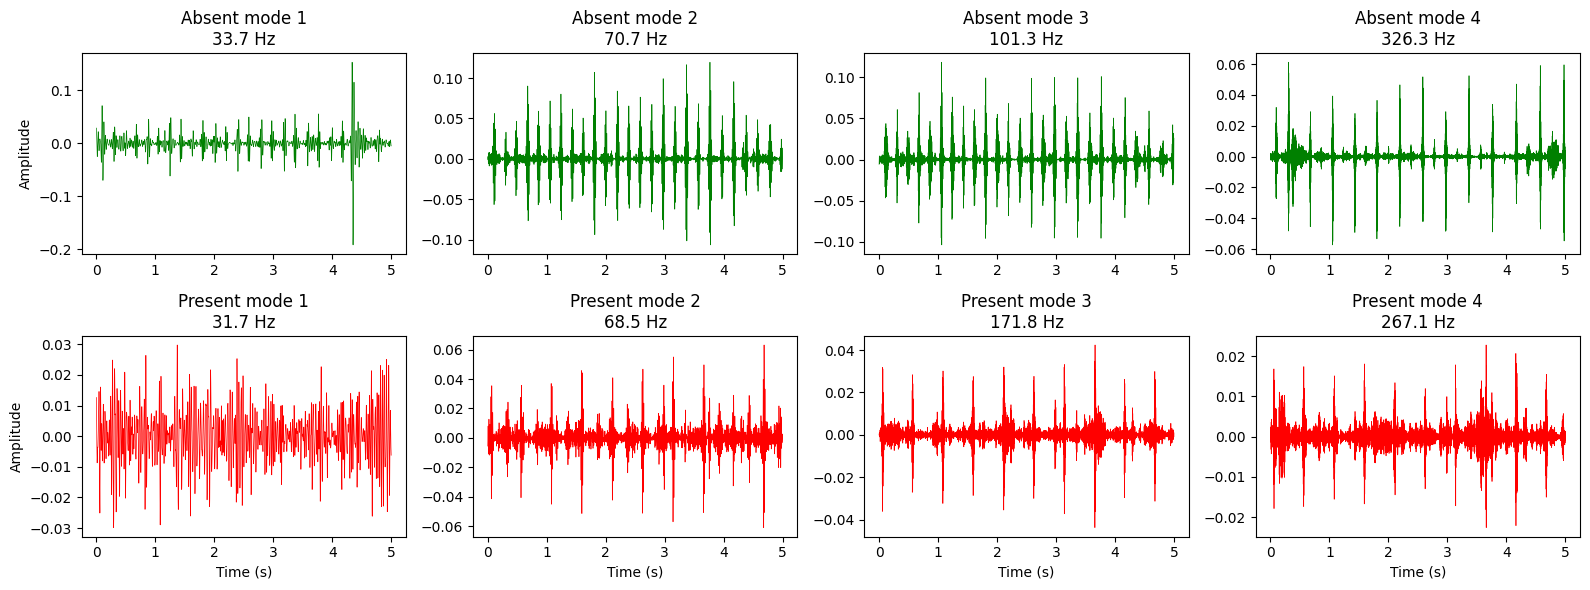

In [14]:
# comparing modes side by side

fig, axes = plt.subplots(2, K, figsize=(16, 6))

for k in range(K):
    axes[0, k].plot(time_axis, u_absent[k], 'g', linewidth=0.5)
    axes[0, k].set_title(f'Absent mode {k+1}\n{omega_absent[k]*SAMPLE_RATE:.1f} Hz')
    if k == 0:
        axes[0, k].set_ylabel('Amplitude')

    axes[1, k].plot(time_axis, u_present[k], 'r', linewidth=0.5)
    axes[1, k].set_title(f'Present mode {k+1}\n{omega_present[k]*SAMPLE_RATE:.1f} Hz')
    axes[1, k].set_xlabel('Time (s)')
    if k == 0:
        axes[1, k].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'jmd_mode_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving JMD as a reusable module

In [15]:
# writing the JMD algorithm to a standalone .py file

jmd_module_code = '''"""Jump Plus AM-FM Mode Decomposition (JMD) - Memory Efficient Version"""

import numpy as np
from scipy.fft import fft, ifft, fftshift, ifftshift
from scipy.sparse import spdiags, eye as speye
from scipy.sparse.linalg import spsolve


def mirror_extend_matlab(signal):
    """Mirror-extend signal to length 2T."""
    T = len(signal)
    T_half = T // 2
    f = np.zeros(2 * T)
    f[0:T_half] = signal[T_half-1::-1]
    f[T_half:T_half + T] = signal
    f[T_half + T:2*T] = signal[T-1:T_half-1:-1]
    return f


def compute_alpha_schedule(alpha, N=2000):
    """Compute alpha warm-up schedule."""
    a2 = 50
    t2 = np.arange(0.01, np.sqrt(2/a2) + 0.001, 0.001)
    phi1 = (-a2/2) * (t2**2) + (np.sqrt(2*a2) * t2)
    phi = np.concatenate([phi1, np.ones(N - len(phi1))])
    return alpha * phi


def JMD(signal, alpha=5000, tau=5, beta=0.03, b_bar=0.45, K=3, init=0, tol=1e-6):
    """
    Jump Plus AM-FM Mode Decomposition (JMD) - Memory Efficient.

    Parameters:
        signal : 1D array
        alpha  : bandwidth constraint
        tau    : dual ascent step
        beta   : jump constraint (1/expected jumps)
        b_bar  : jump height parameter
        K      : number of modes
        init   : 0=zeros, 1=uniform, 2=random
        tol    : convergence tolerance

    Returns:
        u     : (K, T) decomposed modes
        v     : (T,) jump component
        omega : (K,) final center frequencies
    """
    shift = np.mean(signal)
    signal = signal - shift
    save_T = len(signal)
    fs = 1.0 / save_T

    f = mirror_extend_matlab(signal)
    T = len(f)
    t = np.arange(1, T + 1) / T
    freqs = t - 0.5 - 1/T

    N = 2000
    Alpha = compute_alpha_schedule(alpha, N)

    f_hat = fftshift(fft(f))
    f_hat_plus = f_hat.copy()
    f_hat_plus[:T//2] = 0

    u_hat_curr = np.zeros((T, K), dtype=np.complex128)
    u_hat_prev = np.zeros((T, K), dtype=np.complex128)
    omega_curr = np.zeros(K)
    omega_prev = np.zeros(K)

    if init == 1:
        for i in range(K):
            omega_prev[i] = (0.5 / K) * i
    elif init == 2:
        omega_prev[:] = np.sort(np.exp(np.log(fs) + (np.log(0.5) - np.log(fs)) * np.random.rand(K)))

    uDiff = tol + np.finfo(float).eps
    n = 0

    b = 2.0 / (b_bar ** 2)
    gamma = tau * (0.5 * b * beta)
    v = np.zeros(T)

    d = np.ones(T)
    D = spdiags(np.vstack([-d, d]), np.array([0, 1]), T, T, format=\"lil\")
    D[-1, :] = 0
    D = D.tocsr()
    DTD = D.T @ D

    x = np.zeros(T)
    rho = np.zeros(T)
    coef1 = 1.0 / gamma if gamma > 0 else 0
    mu = 2 * beta / gamma if gamma > 0 else 0
    SPDiag = speye(T, format=\"csr\")
    j_hat_curr = np.zeros(T, dtype=np.complex128)
    j_hat_prev = np.zeros(T, dtype=np.complex128)

    if gamma > 0:
        v_update_matrix = SPDiag + gamma * DTD

    while uDiff > tol and n < N - 1:
        sum_uk = np.sum(u_hat_prev, axis=1) - u_hat_prev[:, 0]

        for k in range(K):
            if k > 0:
                sum_uk = sum_uk + u_hat_curr[:, k-1] - u_hat_prev[:, k]

            denom = 1 + Alpha[n] * (freqs - omega_prev[k])**2
            u_hat_curr[:, k] = (f_hat_plus - sum_uk - j_hat_prev) / denom

            pos_freqs = freqs[T//2:]
            pos_power = np.abs(u_hat_curr[T//2:, k])**2
            sum_power = np.sum(pos_power)
            if sum_power > 0:
                omega_curr[k] = np.sum(pos_freqs * pos_power) / sum_power

        u_hat_full = np.zeros((T, K), dtype=np.complex128)
        for k in range(K):
            u_hat_full[T//2:, k] = u_hat_curr[T//2:, k]
            u_hat_full[T//2:0:-1, k] = np.conj(u_hat_curr[T//2:, k])
            u_hat_full[0, k] = np.conj(u_hat_full[-1, k])

        u = np.zeros((K, T))
        for k in range(K):
            u[k, :] = np.real(ifft(ifftshift(u_hat_full[:, k])))

        if gamma > 0:
            rhs = (gamma * D.T @ x - D.T @ rho) + f - np.sum(u, axis=0)
            v = spsolve(v_update_matrix, rhs)
        else:
            v = f - np.sum(u, axis=0)

        Dv = D @ v
        h = Dv + coef1 * rho

        if mu * b < 1:
            abs_h = np.abs(h) + 1e-10
            scale = np.clip((1.0 / (1 - mu * b)) - (mu * np.sqrt(2 * b) / (1 - mu * b)) / abs_h, 0, 1)
            x = scale * h
        else:
            x = np.zeros_like(h)

        rho = rho - gamma * (x - Dv)
        v = v - (np.mean(v) - np.mean(f))

        j_hat_curr[:] = fftshift(fft(v))
        j_hat_curr[:T//2] = 0

        n += 1

        uDiff = np.finfo(float).eps
        for k in range(K):
            diff = u_hat_curr[:, k] - u_hat_prev[:, k]
            uDiff += (1/T) * np.sum(diff * np.conj(diff)).real
        j_diff = j_hat_curr - j_hat_prev
        uDiff += (1/T) * np.sum(j_diff * np.conj(j_diff)).real
        uDiff = np.abs(uDiff)

        u_hat_prev[:] = u_hat_curr
        omega_prev[:] = omega_curr
        j_hat_prev[:] = j_hat_curr

    u_hat_final = np.zeros((T, K), dtype=np.complex128)
    u_hat_final[T//2:, :] = u_hat_curr[T//2:, :]
    u_hat_final[T//2:0:-1, :] = np.conj(u_hat_curr[T//2:, :])
    u_hat_final[0, :] = np.conj(u_hat_final[-1, :])

    u = np.zeros((K, T))
    for k in range(K):
        u[k, :] = np.real(ifft(ifftshift(u_hat_final[:, k])))

    u = u[:, T//4:3*T//4]
    v = v[T//4:3*T//4] + shift

    sort_idx = np.argsort(omega_curr)
    u = u[sort_idx, :]
    omega_final = omega_curr[sort_idx]

    return u, v, omega_final
'''

decomp_dir = PROJECT_ROOT / 'decomposition'
decomp_dir.mkdir(exist_ok=True)

with open(decomp_dir / 'jmd.py', 'w') as f:
    f.write(jmd_module_code)

print(f"Module saved: {decomp_dir / 'jmd.py'}")

Module saved: D:\sop\decomposition\jmd.py


In [16]:
# testing the saved module import

import sys
sys.path.insert(0, str(decomp_dir))

import importlib
import jmd as jmd_module
importlib.reload(jmd_module)
from jmd import JMD as JMD_imported

test_sig = np.sin(2 * np.pi * 10 * np.linspace(0, 1, 1000))
u_test, v_test, omega_test = JMD_imported(test_sig, K=2, alpha=1000, tol=1e-5)
print(f"Import test passed.")
print(f"Output shapes: u={u_test.shape}, v={v_test.shape}, omega={omega_test.shape}")

Import test passed.
Output shapes: u=(2, 1000), v=(1000,), omega=(2,)


## Performance estimate

In [17]:
# estimating processing time for the full dataset
# using the timings from the two PCG tests above

n_total = len(df)
avg_duration = df['duration'].mean()
avg_samples = int(avg_duration * SAMPLE_RATE)

print(f"Dataset: {n_total} files")
print(f"Average signal: {avg_duration:.1f}s ({avg_samples} samples)")

Dataset: 7173 files
Average signal: 22.6s (22615 samples)
